 Image loaded. Generating plots...


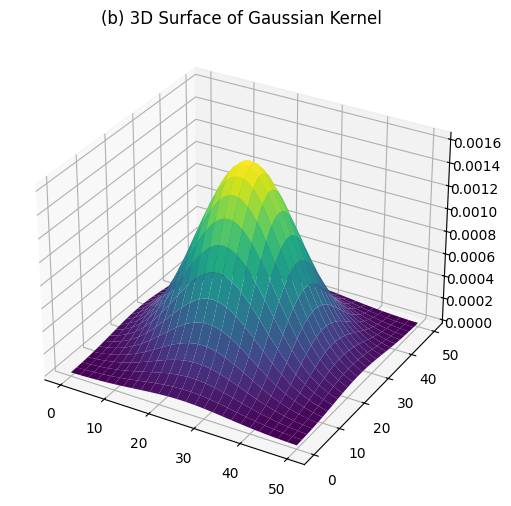

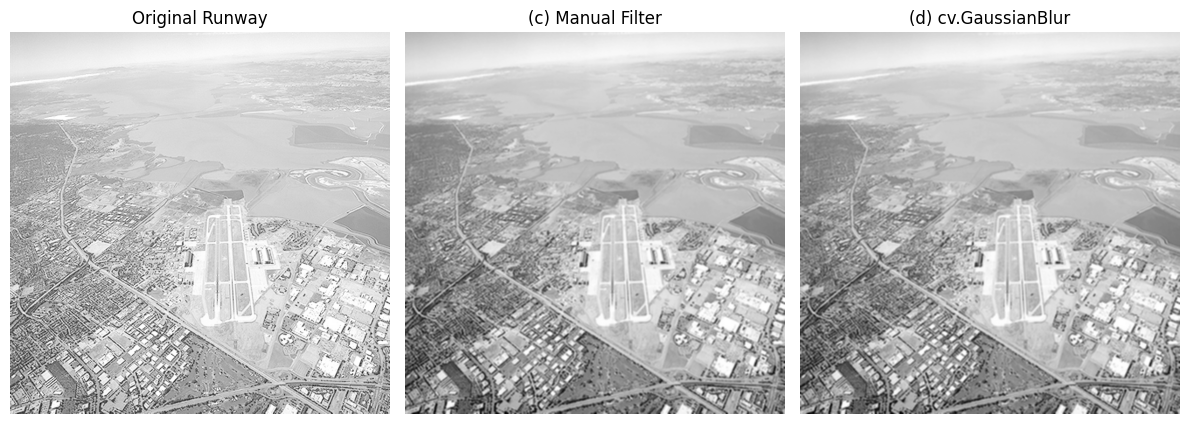

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Standard import for 3D plots


#  Manual Gaussian Kernel
def get_gaussian_kernel(size , sigma):
    center = size // 2
    kernel = np.zeros((size , size))
    for x in range(size):
        for y in range(size):
            # Calculate squared distance from center
            diff_sq = (x - center) ** 2 + (y - center) ** 2
            # Apply Gaussian Formula
            kernel[x , y] = np.exp(-diff_sq / (2 * sigma ** 2))
    return kernel / np.sum(kernel)  # Normalize so sum = 1


#
filename = 'runway.png'
file_path = fr"d:\computer_Vision_Inclass_11_26\{filename}"

# Load Image
img = cv.imread(file_path , cv.IMREAD_GRAYSCALE)

if img is None:
    print(" ERROR: Image not found.")
else:
    print(" Image loaded. Generating plots...")

    #  3D Visualization (The Top Graph)
    #  Use a large kernel  and large sigma  to make it look smooth and nice
    sigma_viz = 10
    size_viz = 51
    kernel_51 = get_gaussian_kernel(size_viz , sigma_viz)

    plt.figure(figsize=(12, 5))
    ax = fig.add_subplot(111 , projection='3d')

    # Create the grid for plotting
    x = np.arange(0 , size_viz , 1)
    y = np.arange(0 , size_viz , 1)
    X , Y = np.meshgrid(x , y)

    # Plot Surface with a nice color map ('viridis')
    ax.plot_surface(X , Y , kernel_51 , cmap='viridis' , linewidth=0 , antialiased=True)
    ax.set_title('(b) 3D Surface of Gaussian Kernel')
    plt.show()  # <--- This displays the first graph (Top)

    #  Image Filtering
    # The actual processing with a smaller kernel
    sigma = 2
    kernel_5x5 = get_gaussian_kernel(5 , sigma)

    # Apply Manual Filter
    img_manual = cv.filter2D(img , -1 , kernel_5x5)

    # Apply OpenCV Built-in Filter
    img_builtin = cv.GaussianBlur(img , (5 , 5) , sigma)

    # Display Comparison
    plt.figure(figsize=(12 , 5))  # <--- Fixed the typo here!

    #  Original
    plt.subplot(1 , 3 , 1)
    plt.imshow(img , cmap='gray')
    plt.title('Original Runway')
    plt.axis('off')

    #  Manual Result
    plt.subplot(1 , 3 , 2)
    plt.imshow(img_manual , cmap='gray')
    plt.title('(c) Manual Filter')
    plt.axis('off')

    #  Built-in Result
    plt.subplot(1 , 3 , 3)
    plt.imshow(img_builtin , cmap='gray')
    plt.title('(d) cv.GaussianBlur')
    plt.axis('off')

    plt.tight_layout()
    plt.show()  # <--- This displays the second graph (Bottom)